In [1]:
%matplotlib widget
import os
import torch, einops
import matplotlib.pyplot as plt
import numpy as np

from util import configure_logging, download_and_concat, textfile_to_tokens_as_binary, get_batch
from tokenizer import train_bpe, Tokenizer
from transformer import Embedding, TransformerBlock, RMSNorm, Linear, MultiHeadAttention, TransformerLM

configure_logging()  # or configure_logging(logging.DEBUG) for verbose

In [2]:
# download some internet text
urls = [
    "https://gutenberg.org/cache/epub/1184/pg1184.txt",
    "https://gutenberg.org/cache/epub/1513/pg1513.txt",
]
download_and_concat(urls, "data/combined.txt", separator="\n<|endoftext|>\n")

08:38:29 util INFO [1/2] downloading https://gutenberg.org/cache/epub/1184/pg1184.txt
08:38:30 util INFO [2/2] downloading https://gutenberg.org/cache/epub/1513/pg1513.txt
08:38:31 util INFO wrote data/combined.txt (2,956,643 bytes)


In [2]:
# tokenize this text
special_tokens = ["<|endoftext|>", "<|begin|>", "<|end|>"]
path = "data/combined.txt"
vocabulary_size = 1000

vocab, merges = train_bpe(path, vocabulary_size, special_tokens)
tokenizer = Tokenizer(vocab, merges, special_tokens)

pretokenizing and building frequency map: 100%|██████████| 2.96M/2.96M [00:00<00:00, 16.4MB/s]
merging pairs: 100%|██████████| 741/741 [00:04<00:00, 149.26it/s]


In [15]:
# convert the file into a raw-binary which we can read as mmmap.
textfile_to_tokens_as_binary("data/combined.txt","data/train.bin", tokenizer, "wb")
#os.path.getsize("data/train.bin")
data = np.memmap("data/train.bin", dtype=np.uint16, mode="r")
# get_batch(data, 20, 5) returns 20 batches of length 5 sequences inputs,labels

In [16]:
#initialize the model
context_length = 100
d_model = 100
num_heads = 2
num_layers = 3
rope_theta = 10000
model = TransformerLM(vocabulary_size, context_length, num_layers, d_model, 4 * d_model, num_heads, rope_theta)

In [17]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(),lr=0.01)

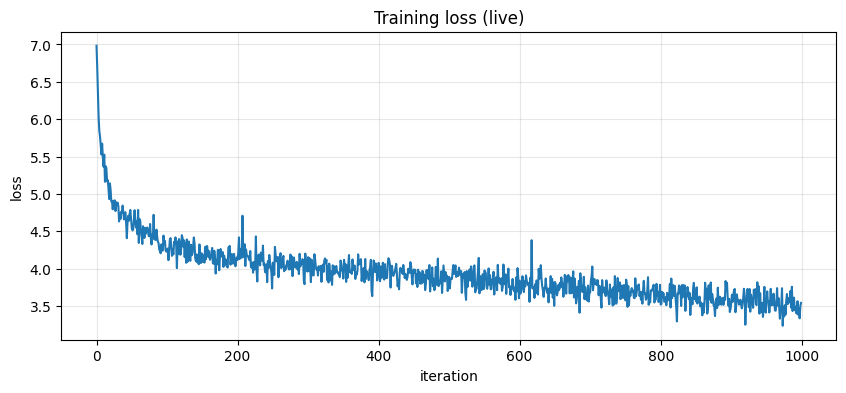

training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [18]:
%matplotlib inline
from tqdm.auto import tqdm
from util import LiveLossPlot

batch_size = 10
iterations = 1000
device = "cpu"

with LiveLossPlot(every=50) as plot:
    pbar = tqdm(range(iterations), desc="training")
    for iteration in pbar:
        inputs, targets = get_batch(data, batch_size, context_length, device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs.transpose(1, 2), targets)
        loss.backward()
        optimizer.step()

        plot.log(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

In [ ]:
batch_size = 100
iterations = 100
device = 'cpu'
for iteration in range(iterations):
    inputs, targets = get_batch(data,batch_size,context_length,device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = loss_function(outputs.transpose(1,2),targets)
    loss.backward()
    optimizer.step()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
plt.matshow(aw.softmax(dim=-1) @ v)

In [ ]:
model = TransformerLM(vocabulary_size, seq_len, 4, d_model, 4 * d_model, 1, 1e5)

In [ ]:
def save_checkpoint(model,optimizer,iteration, out):

In [ ]:
model.state_dict()